# Reto: Covid-19 en México

**Objetivos:** 

* Identificar y clasificar la información del problema con el que se desea trabajar. 
* Integrar los conocimientos adquiridos para manipular la información disponible en un archivo de texto. 
* Sintetizar los datos disponibles a través de Python.

## Descarga y exploración

Descargarmos el archivo **Casos_confirmados.csv** de [Keagle](https://www.kaggle.com/datasets/lalish99/covid19-mx/data?select=casos_confirmados.csv). Importamos con `open` y exploramos el contenido con `archivo.read()`.

Los datos se dividen en $6$ columnas 

| id | State |Sex | Age | Date | Confirmed |
| -- | -- | -- | -- | -- | -- |

In [ ]:
casos_confirmados = open('casos_confirmados.csv', 'r') # Importamos los datos del archivo csv
print(casos_confirmados.read()) # Mostramos los datos

# Recuperar datos

Iteramos sobre cada uno de los renglones con el fin de recuperar la edad y el gérnero de cada paciente. La cantidad de cada **género** lo almacenamos en dos contadores de tipo *int* `masculino` y `femenino`. Las **edad** la vamos a almacenar en un disccionario `edad = {}` donde cada *llave* va a ser *la edad* y cada *valor* la *frecuencia de la edad*. Como dato extra extraemos los estados en un diccionario `estados = {}` donde se van almacenar el número de infectados por estado donde la *llave* es el *nombre del estado* y el *valor* es la *frecuencia del estado*. Otro dato interesante son las fechas en las que se fueron dando los casos positivos, estas las vamos a almacenar en un diccionario `fechas = {}`.

Ignoramos el primer renglon usando el método de `first = True`. Como realizamos un vistazo al archivo debemos colocar el cursor de nuevo al inicio con `casos_confirmados.seek(0)`.

In [ ]:
casos_confirmados.seek(0) # Volver al inicio
first = True # Bool para ignorar el primer renglón
masculino = 0 # Contador de contagiados masculinos
femenino = 0 # Contador de contagiados femeninos
estado = {} # Diccionario para almacenar la frecuencia de los estados
edad = {} # Diccionario para almacenar la frecuencia de las edades
fecha = {} # Diccionario para almacenar la frecuencia de las fechas
for line in casos_confirmados:
    if not first:
        parts = line.split(',') # Separamos los datos por comas
        estado[parts[1]] = estado.get(parts[1],0)+1 # Agrega +1 al estado del renglón
        edad[parts[3]] = edad.get(parts[3],0) + 1 # Agrega +1 a la edad del renglón
        fecha[parts[4]] = fecha.get(parts[4],0) + 1 # Agrega +1 a la fecha del renglón
        if parts[2] == "MASCULINO":
            masculino += 1 # Agrega +1 al contador masculino
        elif parts[2] == "FEMENINO":
            femenino += 1 # Agrega +1 al contador femenino
    first = False # Cambia con el primer renglón



## Análisis estadístico

### Función para calcular cuartiles

In [52]:
def cuartiles(dato,datos):
    # Calculamos los quantiles
    # Aprovechamos que la lista es ordenada de menor a mayor
    min = datos[0] # El primer elemento de una lista ordenada de forma ascendente
    max = datos[-1] # El último elemento de una lista ordenada de forma ascendente
    cont = 0 # Contador del número de datos
    # Bool's para cortar el proceso al llegar a los procentajes de datos buscados
    q2_bol = False
    q3_bol = False
    q4_bol = False
    for k,v in dato.items():
        cont += v # agrega el npumero de datos de la entrada
        if cont >= 0.25*(masculino+femenino) and not q2_bol:
            q2 = k
            q2_bol = True
        elif cont >= 0.5*(masculino+femenino) and not q3_bol:
            q3 = k
            q3_bol = True
        elif cont >= 0.75*(masculino+femenino) and not q4_bol:
            q4 = k
            q4_bol = True
            break
    # Imrpimimos la información obtenida
    print('\nCuartiles')
    print(f'Min: {min}')
    print(f'q2 (25%): {q2}')
    print(f'q3 (50%): {q3}')
    print(f'q4 (75%): {q4}')
    print(f'Max: {max}')

### Género

Esta es la información obtenida. Podemos ver que hubo en ese intervalo de tiempo más hombres que mujeres contagiados.
* Hombres = $198358$ infectados
* Mujeres = $172354$ infectados

<div align='center'>

| Hombres | Mujeres |
| -- | -- |
| $53.51$ % | $46.49$ % |

</div>

In [ ]:
# Imprimimos las estadísticas
print(f"Total de casos confirmados: {masculino + femenino}\n")
print(f"Casos confirmados de masculino: {masculino}")
print(f"Casos confirmados de femenino: {femenino}\n")
print(f"Porcentaje de casos confirmados de masculino: {round(masculino / (masculino + femenino)*100,2)} %")
print(f"Porcentaje de casos confirmados de femenino: {round(femenino / (masculino + femenino)*100,2)} %")

Total de casos confirmados: 370712

Casos confirmados de masculino: 198358
Casos confirmados de femenino: 172354

Porcentaje de casos confirmados de masculino: 53.51 %
Porcentaje de casos confirmados de femenino: 46.49 %


### Edad

Con la información de la edad almacenada en el diccionario `edad` calcularemos la **edad promedio** con una suma ponderada, donde los pesos son las frecuencias $$\frac{\sum llave*valor}{\sum valor}$$
Para eso tenemos que convertir la llave en entero.

Haciendo el calculo obtenemos que:

**Edad promedio = $45$ años**

In [5]:
# Convertimos las llaves de edad a entero
edad = {int(k):int(v) for k,v in edad.items()}
# Ordenamos de menor a mayor por las llaves
edad = dict(sorted(edad.items()))
# Separamos las edades y las frecuencias
edades = list(edad.keys())
frecuencia_por_edad = list(edad.values())

# Calculamos el promedio de edades
producto = 0
for k in range(len(edades)):
    producto += edades[k]*frecuencia_por_edad[k]
edad_promedio = int(producto / sum(frecuencia_por_edad))
print(f'La edad promedio de los casos de infectados es: {edad_promedio} años')

La edad promedio de los casos de infectados es: 45 años


#### Histograma de Edades

Edad: Frecuencia de edad (Ordenados) -> {0: 768, 1: 537, 2: 326, 3: 294, 4: 300, 5: 276, 6: 329, 7: 319, 8: 358, 9: 349, 10: 424, 11: 475, 12: 478, 13: 614, 14: 645, 15: 752, 16: 882, 17: 1052, 18: 1167, 19: 1809, 20: 2306, 21: 2767, 22: 3123, 23: 4021, 24: 4957, 25: 5833, 26: 6731, 27: 7173, 28: 7498, 29: 7721, 30: 8384, 31: 8102, 32: 7960, 33: 8073, 34: 8263, 35: 8313, 36: 8333, 37: 8585, 38: 8429, 39: 8260, 40: 8487, 41: 7948, 42: 8027, 43: 8190, 44: 8274, 45: 8486, 46: 8456, 47: 8405, 48: 8314, 49: 7861, 50: 7799, 51: 7505, 52: 7389, 53: 6966, 54: 6684, 55: 6668, 56: 6713, 57: 6268, 58: 5842, 59: 5760, 60: 5459, 61: 5063, 62: 4484, 63: 4695, 64: 4148, 65: 4164, 66: 3919, 67: 3637, 68: 3491, 69: 3166, 70: 3092, 71: 2692, 72: 2586, 73: 2396, 74: 2184, 75: 2113, 76: 1898, 77: 1795, 78: 1757, 79: 1399, 80: 1402, 81: 1137, 82: 1050, 83: 983, 84: 901, 85: 769, 86: 632, 87: 580, 88: 435, 89: 377, 90: 346, 91: 200, 92: 172, 93: 126, 94: 98, 95: 94, 96: 68, 97: 49, 98: 52, 99: 23, 100: 32, 

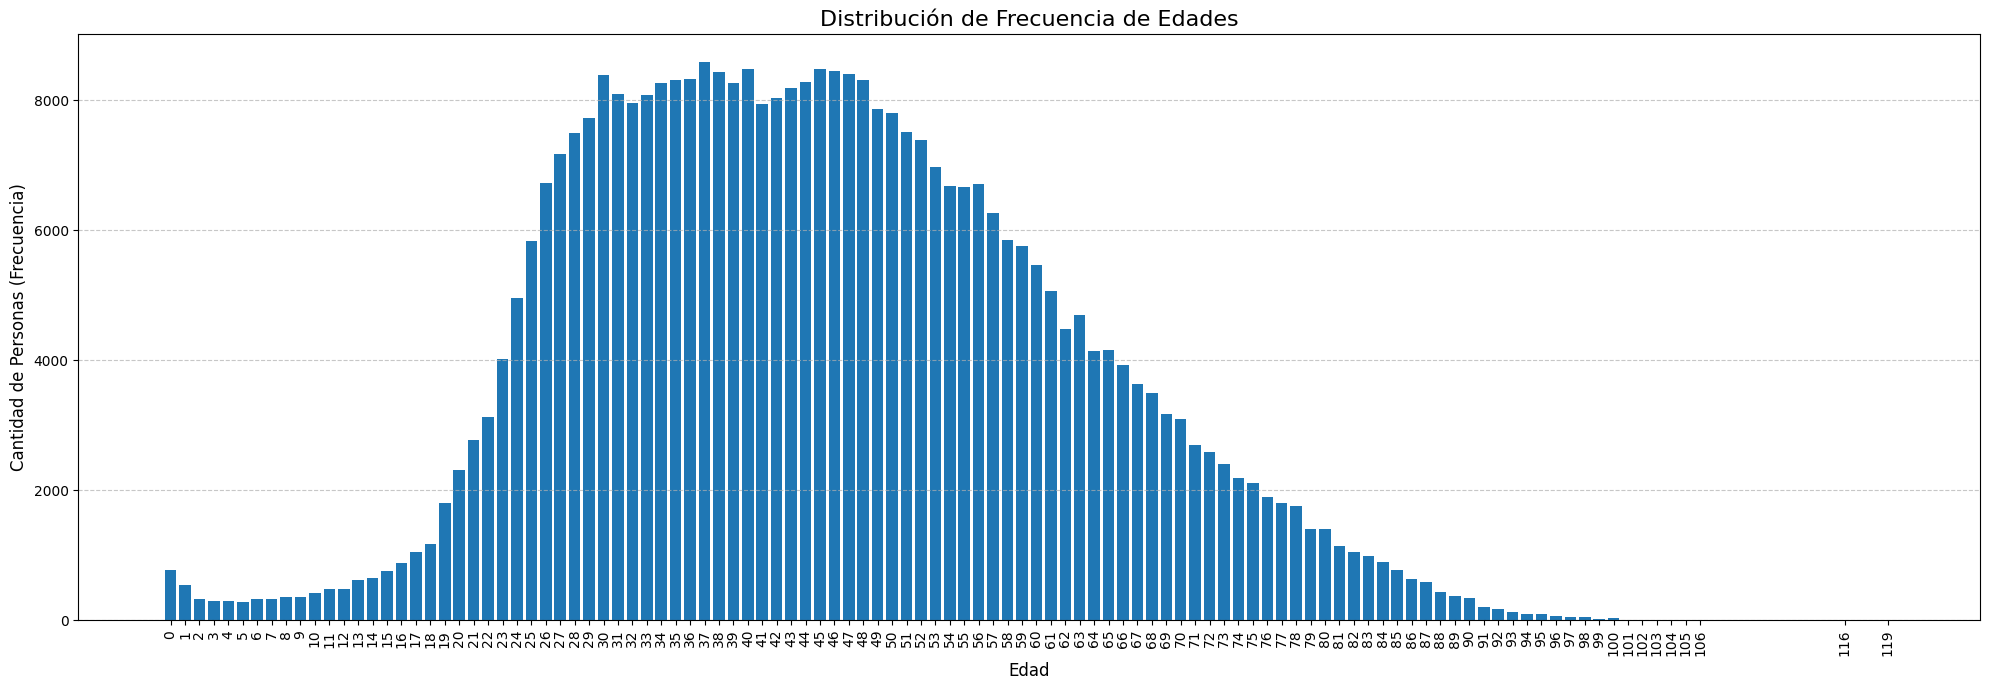

In [47]:
import matplotlib.pyplot as plt

print(f'Edad: Frecuencia de edad (Ordenados) -> {edad}')
plt.figure(figsize=(20, 7))
plt.bar(edades,frecuencia_por_edad,width=0.8,align='center')
plt.title('Distribución de Frecuencia de Edades', fontsize=16)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Cantidad de Personas (Frecuencia)', fontsize=12)
plt.xticks(edades, rotation= 90) # Asegura que haya una marca para cada edad y rota las etiquetas 90°
plt.tight_layout() # Evita que las etiquetas se corten
plt.grid(axis='y', linestyle='--', alpha=0.7)



In [50]:
# Calculamos la desviación estandar
num_des = [v*(k-edad_promedio)**2 for k,v in edad.items()]
desv_est = round((sum(num_des)/sum(frecuencia_por_edad))**0.5,2)
print(f'La desviación estandar es: {desv_est}')
cuartiles(edad,edades)




La desviación estandar es: 16.41

Cuartiles
Min: 0
q2 (25%): 33
q3 (50%): 44
q4 (75%): 56
Max: 119


La información obtenida nos indica que el $50$ % de los infectados son personas de entre 33 años y 56 años de edad.

Que en promedio la edad de los infectados es de 45 años.

La edad máxima de los infectados fue de 119 años y la edad mínima fueron bebes de menos de un año de edad.

### Fechas

Los datos registrados corresponden al intervalo de fecha del 2020-01-13 al 2020-07-23

Cuartiles
Min: 2020-01-13
q2 (25%): 2020-05-26
q3 (50%): 2020-06-16
q4 (75%): 2020-07-03
Max: 2020-07-23


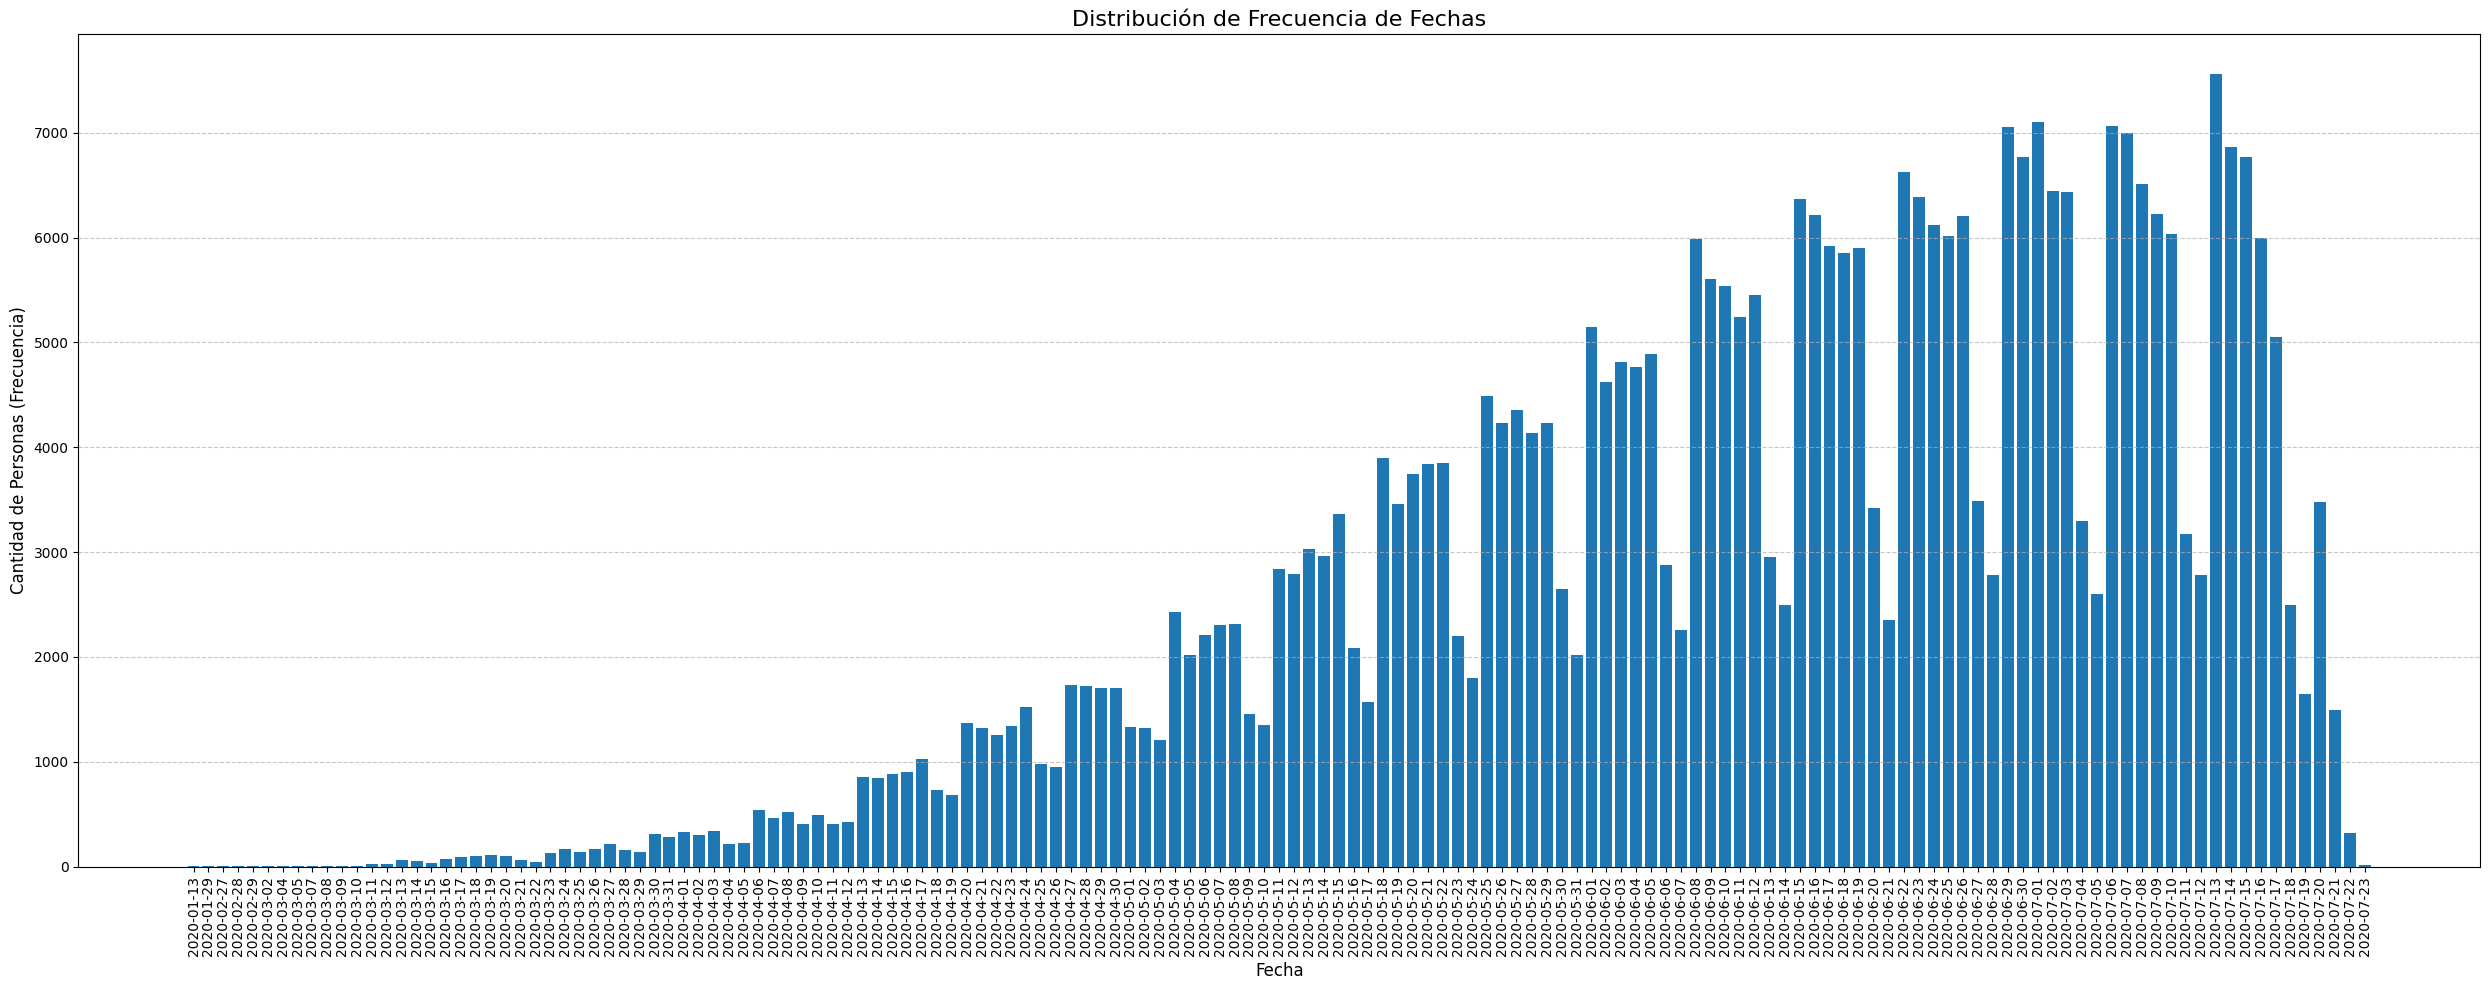

In [53]:
from datetime import date
import matplotlib.pyplot as plt

# Ordenamos las fechas por la más antigua a la más reciente
fecha = dict(sorted(fecha.items(),key = lambda item: date.fromisoformat(item[0])))
fechas = list(fecha.keys())
frecuencias_fechas = fecha.values()
print(f'Los datos registrados corresponden al intervalo de fecha del {fechas[0]} al {fechas[-1]}')

plt.figure(figsize=(25, 10))
plt.bar(fechas,frecuencias_fechas,width=0.8,align='center')
plt.title('Distribución de Frecuencia de Fechas', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Personas (Frecuencia)', fontsize=12)
plt.xticks(fechas, rotation = 90) # Asegura que haya una marca para cada edad y rota las etiquetas 90°
plt.tight_layout() # Evita que las etiquetas se corten
plt.grid(axis='y', linestyle='--', alpha=0.7)
cuartiles(fecha,fechas)

### Estados

Estado con mayor porcentaje de infectados es distrito federal con 17.92 % es decir 66444 infectados.
Le sigue méxico con 13.11 % es decir 48592 infectados.

Los estados tienen un promedio de 11584.75 infectados lo que representa un 3.125 % del total de infectados


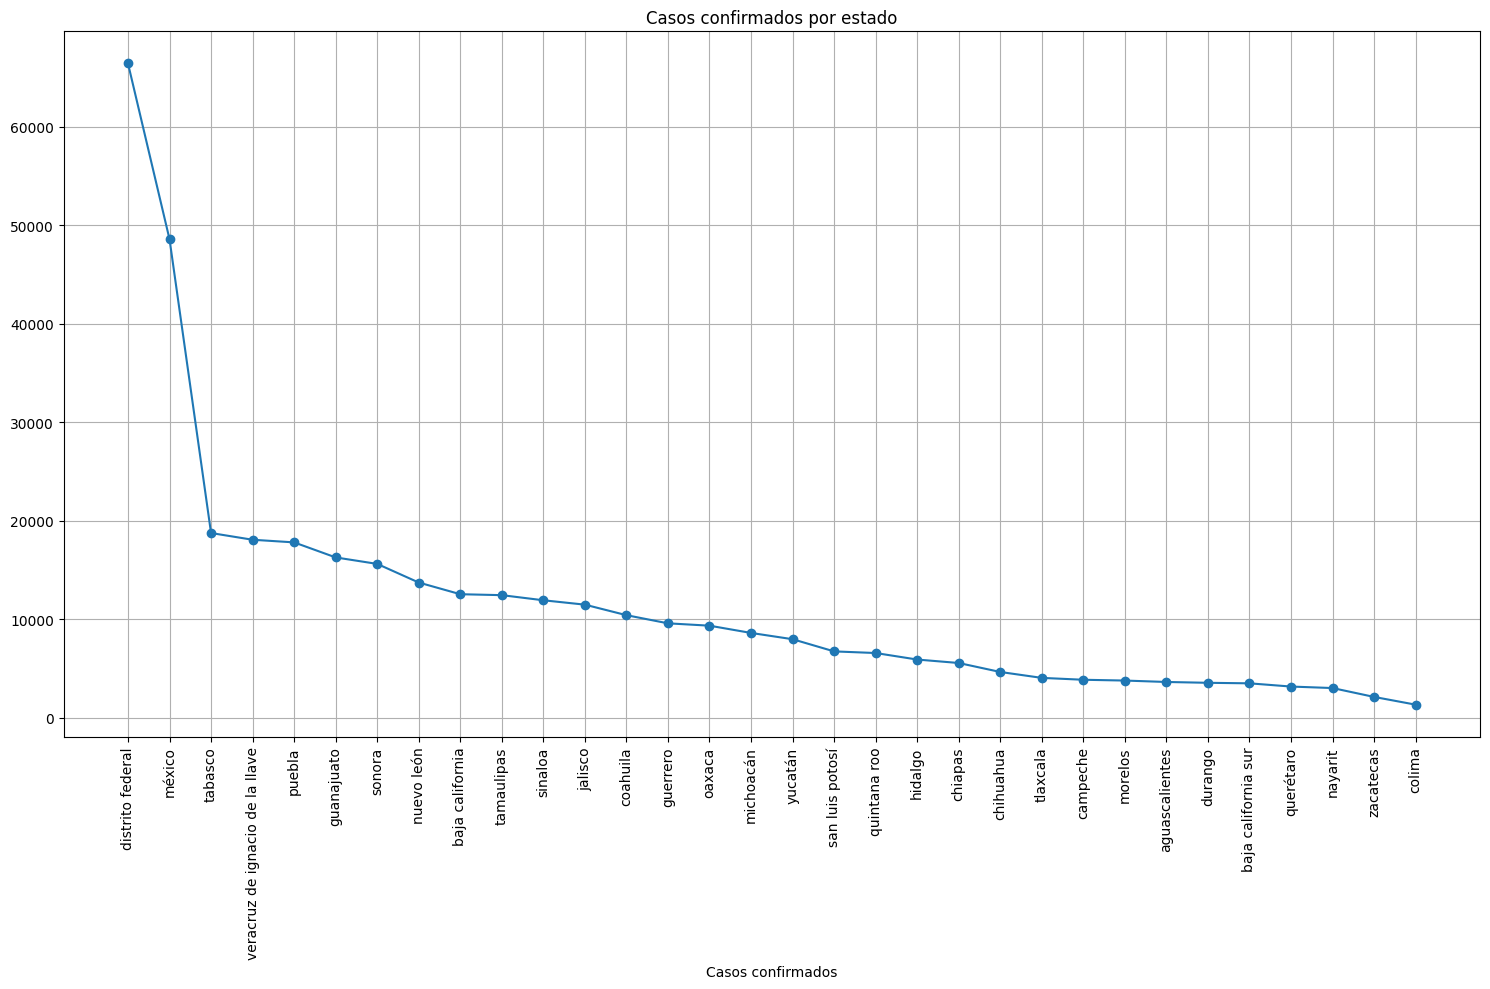

In [36]:
import matplotlib.pyplot as plt

# Primero ordenamos los datos de mayor a menor con sorted()
estado = dict(sorted(estado.items(), key = lambda item : item[1],reverse = True))

estados = list(estado.keys())       
frecuencia_estados = list(estado.values())

plt.figure(figsize=(15,10))
plt.plot(estados,frecuencia_estados,marker = 'o')
plt.title("Casos confirmados por estado")
plt.xlabel("Estado")
plt.xlabel("Casos confirmados")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
print(f'Estado con mayor porcentaje de infectados es {estados[0]} con {round(frecuencia_estados[0]/(masculino+femenino)*100,2)} % es decir {frecuencia_estados[0]} infectados.')
print(f'Le sigue {estados[1]} con {round(frecuencia_estados[1]/(masculino+femenino)*100,2)} % es decir {frecuencia_estados[1]} infectados.')

promedio_estados = sum(frecuencia_estados)/len(estados)
print(f'\nLos estados tienen un promedio de {promedio_estados} infectados lo que representa un {promedio_estados/(masculino+femenino)*100} % del total de infectados')


Pareciera que la **Ciudad de México** y el **Estado de México** son dos datos atípicos, ambos concentrarón en esas fechas el $31$ % de todos los infectados en el país es decir casi la tercera parte.